# System-Effect Analysis (§8.1 Training-data axis & §8.3 Decoder axis)

Hypothesis-space coverage analysis on candidate-distribution probe dumps from
`results/system_effect/`, rendered in the same plotting style as
`n_support_scaling.ipynb` and `training_scale_analysis.ipynb` for consistency
with the rest of the paper.

The five fingerprint axes — coverage, quality, concentration, surface form,
targeting — are defined in `experimental/system_effect/diagnostic.py`. Each is
plotted as a metric vs *fit_time* (test-time compute) panel with bootstrap
95% CI bands, OOB indicators, and arrow-notation titles indicating objective
direction and natural range.


In [10]:
import os
import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from simplipy import SimpliPyEngine

from flash_ansr import get_path
from flash_ansr.eval.metrics import bootstrapped_metric_ci, naninfmean
from flash_ansr.eval import arrow_notation

# Local diagnostic + cached fingerprint loader + classical-metric derivation
SYS_EFFECT_DIR = Path(get_path()) / 'experimental' / 'system_effect'
sys.path.insert(0, str(SYS_EFFECT_DIR))
from diagnostic import compute_sample_fingerprints_cached, derive_classical_metrics  # noqa: E402


In [11]:
DUMP_DIR = Path(get_path('results', 'system_effect'))
FIG_DIR = Path(get_path('results', 'figures', 'system_effect', create=True))
print(f"DUMP_DIR : {DUMP_DIR}  exists={DUMP_DIR.exists()}")
print(f"FIG_DIR  : {FIG_DIR}")

engine = SimpliPyEngine.load('dev_7-3', install=False)


DUMP_DIR : /home/psaegert/Projects/flash-ansr/results/system_effect  exists=True
FIG_DIR  : /home/psaegert/Projects/flash-ansr/results/figures/system_effect


## Load probes and compute fingerprints (cached)

Each entry is `(label, dump_filename) -> per-sample fingerprint list`. The
`results` dict is shaped to match the existing eval notebooks
(`results[model]['results'][test_set][scaling_value][metric] -> array`) so
the same plotting loop works without modification.


In [12]:
# Probe inventory: (group_label, model_key, choices, dump_filename)
PROBES = [
    # A-track: training-data axis (S100 = SimpliPy, U100 = Unsimplified) at 100M expressions
    ('A', 'v23.0-20M-A-S100',         64,   'cand_dist_v23.0-20M-A-S100_choices00064_n300.pkl'),
    ('A', 'v23.0-20M-A-S100',         256,  'cand_dist_v23.0-20M-A-S100_choices00256_n300.pkl'),
    ('A', 'v23.0-20M-A-S100',         2048, 'cand_dist_v23.0-20M-A-S100_choices02048_n300.pkl'),
    ('A', 'v23.0-20M-A-S100',         4096, 'cand_dist_v23.0-20M-A-S100_choices04096_n300.pkl'),  # 10s anchor
    ('A', 'v23.0-20M-A-U100',         64,   'cand_dist_v23.0-20M-A-U100_choices00064_n300.pkl'),
    ('A', 'v23.0-20M-A-U100',         256,  'cand_dist_v23.0-20M-A-U100_choices00256_n300.pkl'),
    ('A', 'v23.0-20M-A-U100',         2048, 'cand_dist_v23.0-20M-A-U100_choices02048_n300.pkl'),
    ('A', 'v23.0-20M-A-U100',         4096, 'cand_dist_v23.0-20M-A-U100_choices04096_n300.pkl'),  # 10s anchor
    # 20M @ 10M training expressions: SimpliPy vs SymPy comparison at the same training scale
    ('A', 'v23.0-20M-A-S10',          4096, 'cand_dist_v23.0-20M-A-S10_choices04096_n300.pkl'),   # 10s anchor
    ('A', 'v23.0-20M-A-Y10',          4096, 'cand_dist_v23.0-20M-A-Y10_choices04096_n300.pkl'),   # 10s anchor (pending: Y10 still training)
    # Z-track: decoder axis on the same 120M baseline
    ('Z', 'v23.0-120M-softmax',       64,   'cand_dist_v23.0-120M-softmax_choices00064_n300.pkl'),
    ('Z', 'v23.0-120M-softmax',       256,  'cand_dist_v23.0-120M-softmax_choices00256_n300.pkl'),
    ('Z', 'v23.0-120M-softmax',       2048, 'cand_dist_v23.0-120M-softmax_choices02048_n300.pkl'),
    ('Z', 'v23.0-120M-softmax',       4096, 'cand_dist_v23.0-120M-softmax_choices04096_n300.pkl'),  # 10s anchor
    ('Z', 'v23.0-120M-beam',          64,   'cand_dist_v23.0-120M-beam_choices00064_n300.pkl'),
    ('Z', 'v23.0-120M-beam',          256,  'cand_dist_v23.0-120M-beam_choices00256_n300.pkl'),
    ('Z', 'v23.0-120M-beam',          2048, 'cand_dist_v23.0-120M-beam_choices02048_n300.pkl'),
    ('Z', 'v23.0-120M-beam',          4096, 'cand_dist_v23.0-120M-beam_choices04096_n300.pkl'),  # 10s anchor
]

results = {}  # results[model_key]['results'][test_set][scaling_value] -> dict-of-arrays

TEST_SET = 'fastsrb'

for group, model_key, choices, fname in PROBES:
    dump_path = DUMP_DIR / fname
    if not dump_path.exists():
        print(f'[skip] missing {fname}')
        continue

    with open(dump_path, 'rb') as f:
        payload = pickle.load(f)

    cache_path = str(dump_path).replace('.pkl', '.fingerprints.pkl')
    fps = compute_sample_fingerprints_cached(engine, payload['samples'], cache_path)
    if not fps:
        print(f'[empty] {fname}')
        continue

    # Per-sample classical metrics (derived from probe candidates, not cached --- fast).
    classical = [derive_classical_metrics(engine, s, engine.operator_arity)
                 for s in payload['samples']]
    # Realign: derive_classical_metrics is called over all samples, but fps may
    # be shorter if some samples returned empty candidate sets. We use payload
    # order (which matches probe `selected` order); compute_sample_fingerprint
    # returns None for empty samples, so iterate paired.
    classical_aligned = []
    fp_iter = iter(fps)
    for s in payload['samples']:
        cm = derive_classical_metrics(engine, s, engine.operator_arity)
        if not s.get('candidates'):
            continue
        classical_aligned.append(cm)
    classical = classical_aligned

    if len(classical) != len(fps):
        # Defensive guard --- shouldn't happen given identical filtering, but skip mismatched.
        print(f'[warn] {fname}: classical/fps length mismatch ({len(classical)} vs {len(fps)})')
        continue

    # Convert fingerprint dataclasses + classical dicts -> dict-of-arrays for plotting parity
    record = {
        # Compute / cost
        'fit_time':                  np.array([f.fit_time for f in fps]),
        # Five-axis fingerprint (canonical-form-aware, slow-cached)
        'coverage':                  np.array([f.coverage for f in fps]),
        'quality':                   np.array([f.quality for f in fps]),
        'concentration':             np.array([f.concentration for f in fps]),
        'surface_form':              np.array([f.surface_form for f in fps]),
        'targeting':                 np.array([float(f.targeting) for f in fps]),
        # Auxiliary structural counts
        'max_canonical_group_size':  np.array([f.max_canonical_group_size for f in fps]),
        'n_canonical_unique':        np.array([f.n_canonical_unique for f in fps]),
        'canonical_gt_len':          np.array([f.canonical_gt_len for f in fps]),
        # Denominator-free companion metric to Yield: PFD = n_perfect_groups / n_candidates
        # Equivalently: Coverage * Yield. Bootstrapped per-sample for proper CIs (vs. the
        # naive product of CIs which overstates the interval). Avoids the mode-collapse
        # ratio pathology of Yield in cross-decoder comparisons (see paper §5.6).
        'perfect_fit_density':       np.array([
            f.n_perfect_groups / max(f.n_candidates, 1) for f in fps
        ]),
        # Classical metrics derived from candidates (vNRR + structural metrics on best candidate)
        'numeric_recovery_val':      np.array([c['numeric_recovery_val'] for c in classical]),
        'predicted_total_nestedness': np.array([c['predicted_total_nestedness'] for c in classical]),
        'predicted_n_constants':     np.array([c['predicted_n_constants'] for c in classical]),
        'n_constants_delta':         np.array([c['n_constants_delta'] for c in classical]),
    }

    results.setdefault(model_key, {'group': group, 'scaling_parameter': 'choices', 'results': {TEST_SET: {}}})
    results[model_key]['results'][TEST_SET][choices] = record

# Sort scaling values within each model
for k in results:
    by_test = results[k]['results'][TEST_SET]
    results[k]['results'][TEST_SET] = {c: by_test[c] for c in sorted(by_test)}

print('Loaded:')
for k, v in results.items():
    cs = sorted(v['results'][TEST_SET].keys())
    n = len(next(iter(v['results'][TEST_SET].values()))['fit_time'])
    print(f'  {k:<32} group={v["group"]}  choices={cs}  N={n}')

[skip] missing cand_dist_v23.0-20M-A-Y10_choices04096_n300.pkl
Loaded:
  v23.0-20M-A-S100                 group=A  choices=[64, 256, 2048, 4096]  N=287
  v23.0-20M-A-U100                 group=A  choices=[64, 256, 2048, 4096]  N=287
  v23.0-20M-A-S10                  group=A  choices=[4096]  N=287
  v23.0-120M-softmax               group=Z  choices=[64, 256, 2048, 4096]  N=284
  v23.0-120M-beam                  group=Z  choices=[64, 256, 2048, 4096]  N=179


## Metric definitions (4-axis fingerprint + auxiliary)

For a configuration's candidate set on a single test problem with $N$ refined candidates, let $\hat{C} = \{[\bm{\tau}_i]_\mathcal{R}\}_{i=1}^N$ be the multiset of canonical equivalence classes of those candidates under the SimpliPy rule set $\mathcal{R}$, and $|\hat{C}_\text{u}|$ the number of *distinct* canonical hypotheses.

**Four fingerprint axes** (each aggregated across test problems with a bootstrap CI):

| Symbol | Definition | Range | Direction |
|---|---|---|---|
| **Coverage** | $\;|\hat{C}_\text{u}| / N$ | $(0, 1]$ | $\uparrow$ |
| **Hypothesis Yield** | $\;\bigl|\{[\bm{\tau}] \in \hat{C}_\text{u} : \exists \bm{\tau}' \in [\bm{\tau}],\, \mathrm{FVU}(\bm{\tau}') \leq \epsilon_{32}\}\bigr| \;/\; |\hat{C}_\text{u}|$ | $[0, 1]$ | $\uparrow$ |
| **Rewrite Fraction** | $\;1 - \text{Coverage} = (N - |\hat{C}_\text{u}|) / N$ | $[0, 1)$ | $\downarrow$ |
| **Bloat Factor** | $\;\mathbb{E}_i\bigl[|\bm{\tau}_i| \,/\, |\mathrm{simplify}(\bm{\tau}_i)|\bigr]$ | $[1, \infty)$ | $\downarrow$ |

**Auxiliary panels** for context:

| Symbol | Definition | Direction |
|---|---|---|
| **Max Cluster Size** | $\max_{[\bm{\tau}] \in \hat{C}_\text{u}}\; \bigl|\{i : [\bm{\tau}_i] = [\bm{\tau}]\}\bigr|$ | $\downarrow$ |
| **Unique Hypotheses** | $|\hat{C}_\text{u}|$ (absolute count, complementing Coverage's ratio) | $\uparrow$ |

Note: Coverage and Rewrite Fraction are exact complements ($\text{Cov} + \text{Rew} = 1$); we plot both because the visual signature differs (Coverage stays near $1$ for canonicalizing pipelines and is most readable on a tight scale; Rewrite Fraction reads naturally on a log scale and is the more intuitive measure of compute waste).

**On GT-canonical recovery.** The diagnostic does not include a "GT canonical found" indicator as a primary metric, by deliberate methodological choice. Symbolic regression's success criterion is that the recovered expression *fits the data* and is *concise* --- any expression in the GT's equivalence class (under our operator set and the algebraic laws SimpliPy encodes) is an equally valid recovery. A "GT canonical hit rate" would penalize systems that find different but functionally-equivalent (and possibly more parsimonious) representatives of $[\bm{\tau}^*]_\mathcal{R}$, conflating *representation choice* with *correctness*. The four fingerprint axes above are deliberately *form-agnostic*.

`metric_pairs` follows the existing eval-notebook contract: `((x_metric, x_label, x_statistic), (y_metric, y_label, y_statistic, y_factor, ylim))`. Direction is encoded in the title via `arrow_notation(objective=±1, lower=L, upper=U)`.


In [13]:
metric_pairs = [
    (('fit_time', 'Test Time Compute', naninfmean), (
        'coverage',
        f'$\\mathrm{{Coverage}} {arrow_notation(objective=1, lower=0, upper=1)}$',
        np.nanmean, 1, (0.7, 1.01)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'quality',
        f'$\\mathrm{{Hypothesis\\ Yield}}\\,_{{\\mathrm{{FVU}} \\leq \\epsilon_{{32}}}} {arrow_notation(objective=1, lower=0, upper=1)}$',
        np.nanmean, 1, (0, 1)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'concentration',
        f'$\\mathrm{{Rewrite\\ Fraction}} {arrow_notation(objective=-1, lower=0, upper=1)}$',
        np.nanmean, 1, (0, 0.6)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'surface_form',
        f'$\\mathrm{{Bloat\\ Factor}} {arrow_notation(objective=-1, lower=1, upper=np.inf)}$',
        naninfmean, 1, (0.99, 1.7)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'max_canonical_group_size',
        f'$\\mathrm{{Max\\ Cluster\\ Size}} {arrow_notation(objective=-1, lower=1, upper=np.inf)}$',
        naninfmean, 1, (0.5, 60)
    )),
    (('fit_time', 'Test Time Compute', naninfmean), (
        'n_canonical_unique',
        f'$\\mathrm{{Unique\\ Hypotheses}} {arrow_notation(objective=1, lower=0, upper=np.inf)}$',
        naninfmean, 1, (0, 1500)
    )),
]


## Plotting helper

Same plotting loop as `n_support_scaling.ipynb` — errorbar + fill_between for
bootstrap CIs, per-axis OOB indicators, log-scaled x, statistic annotation in
panel corner. Wrapped in a function so we can reuse it for A-track and Z-track
plots.


In [14]:
def plot_track(track_models, *, save_as: str | None, title_suffix: str = ''):
    """Multi-panel plot in the existing eval-notebook style.

    track_models : list of (model_key, scaling_param, color, label).
    """
    track_models = [m for m in track_models if m[0] in results]
    if not track_models:
        print('No models found for this track.')
        return

    cols = min(4, len(metric_pairs))
    rows = int(np.ceil(len(metric_pairs) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.5 * rows), dpi=200)

    for ax_id, (ax, ((x_metric, x_label, x_statistic),
                     (y_metric, y_label, y_statistic, y_factor, ylim))) in enumerate(zip(axes.flatten(), metric_pairs)):
        for model_name, scaling_param, color, model_label in track_models:
            x_med, x_lo, x_hi = [], [], []
            y_med, y_lo, y_hi = [], [], []

            recs = results[model_name]['results'][TEST_SET]
            for n in recs:
                x = recs[n][x_metric]
                y = recs[n][y_metric]
                if y_metric == 'only_approx_log10_fvu_val':
                    y = y[y != -np.inf]

                x_ci = bootstrapped_metric_ci(x, x_statistic, n=1e3, interval=0.95) if len(x) > 0 else (np.nan,)*3
                y_ci = bootstrapped_metric_ci(y, y_statistic, n=1e3, interval=0.95) if len(y) > 0 else (np.nan,)*3

                if not np.isnan(x_ci[0]) and not np.isnan(y_ci[0]):
                    x_med.append(x_ci[0]); x_lo.append(x_ci[1]); x_hi.append(x_ci[2])
                    y_med.append(y_ci[0]); y_lo.append(y_ci[1]); y_hi.append(y_ci[2])

            if not x_med:
                continue

            x_med = np.array(x_med); x_lo = np.array(x_lo); x_hi = np.array(x_hi)
            y_med = np.array(y_med) * y_factor
            y_lo = np.array(y_lo) * y_factor
            y_hi = np.array(y_hi) * y_factor

            if ylim[0] is not None and ylim[1] is not None:
                ax.set_ylim(ylim)

            ax.errorbar(
                x_med, y_med,
                yerr=[y_med - y_lo, y_hi - y_med],
                xerr=[x_med - x_lo, x_hi - x_med],
                fmt='.', label=model_label, capsize=1, color=color,
                elinewidth=1, markersize=4,
            )
            ax.fill_between(x_med, y_lo, y_hi, color=color, alpha=0.1)

            # Out-of-bounds upper-limit indicators (white-filled circles, value annotation)
            if ylim[1] is not None:
                oob = y_med > ylim[1]
                if np.any(oob):
                    ax.plot(
                        x_med[oob], np.full(oob.sum(), ylim[1]),
                        marker='o', linestyle='None',
                        markerfacecolor='white', markeredgecolor=color,
                        markeredgewidth=1.0, markersize=3,
                        clip_on=False, zorder=100,
                    )
                    for x_oob, y_oob in zip(x_med[oob], y_med[oob]):
                        ax.annotate(f"{y_oob:.1f}", xy=(x_oob, ylim[1]), xytext=(0, 1),
                                    textcoords='offset points', ha='center', va='bottom',
                                    fontsize=5, color=color, clip_on=False)

        # Panel-corner statistic annotation
        stat_name = {np.nanmean: 'Mean', np.nanmedian: 'Median', naninfmean: 'Mean w/o inf'}[y_statistic]
        ax.annotate(stat_name, xy=(0.02, 0.97), xycoords='axes fraction',
                    fontsize=8, color='k', ha='left', va='top', alpha=0.4)

        if ax_id // cols == rows - 1:
            ax.set_xlabel(x_label)
        ax.set_title(y_label, fontsize=11)
        ax.set_xscale('log')
        ax.set_xlim(0.04, 1500)
        ax.set_xticks([0.1, 1, 10, 100, 1000])
        ax.set_xticklabels(['0.1s', '1s', '10s', '100s', '1000s'], fontsize=8)
        ax.grid(alpha=0.5)

    if len(track_models) > 0:
        legend_idx = min(len(metric_pairs) - 1, 3)
        axes.flatten()[legend_idx].legend(fontsize=9)

    for ax_id, ax in enumerate(axes.flatten()[len(metric_pairs):]):
        ax.axis('off')

    if title_suffix:
        fig.suptitle(title_suffix, fontsize=12, y=1.005)

    fig.tight_layout(w_pad=1, h_pad=2)
    if save_as is not None:
        out = FIG_DIR / save_as
        fig.savefig(out, dpi=200)
        print(f'Saved {out}')
    plt.show()


## A-track: Training-data axis

S100 (SimpliPy at 100M expressions) vs U100 (Unsimplified at 100M expressions),
both with softmax-sampling decoding. Choices points: 64, 256, 2048.
Color convention: shades of blue for SimpliPy (the canonicalizing pipeline),
shades of orange/red for Unsimplified.


Saved /home/psaegert/Projects/flash-ansr/results/figures/system_effect/a_track_metrics_vs_compute.svg


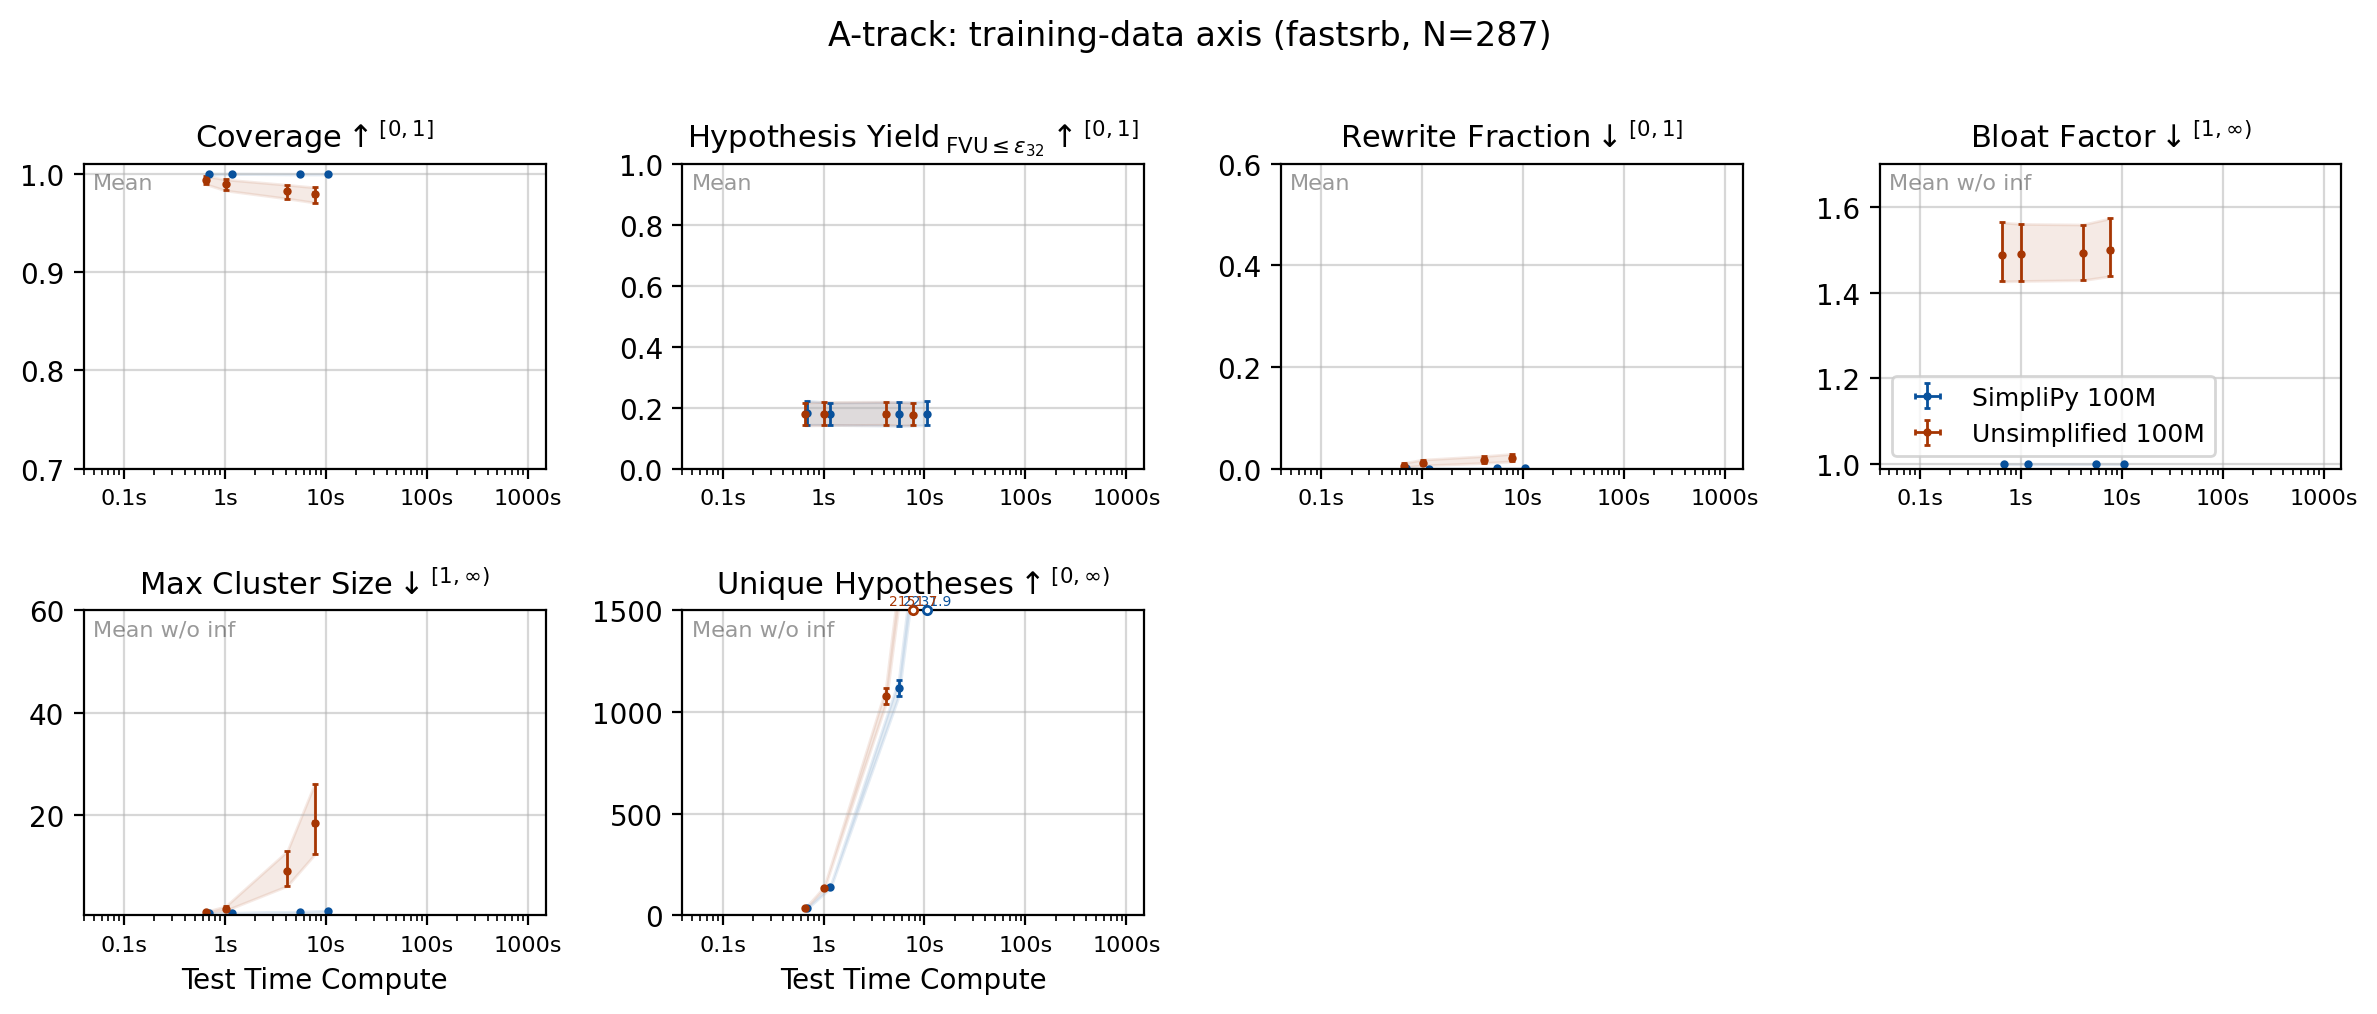

In [15]:
a_track = [
    ('v23.0-20M-A-S100', 'choices', '#08519C', 'SimpliPy 100M'),
    ('v23.0-20M-A-U100', 'choices', '#A63603', 'Unsimplified 100M'),
]
plot_track(a_track, save_as='a_track_metrics_vs_compute.svg', title_suffix='A-track: training-data axis (fastsrb, N=287)')


## Z-track: Decoder axis

Same 120M baseline checkpoint, two decoders. Softmax sampling samples
independently from the model's autoregressive distribution; beam search keeps
the top-K by joint log-probability. Choices/beam_width points: 64, 256, 2048
(beam at 256, 2048 still on Solomon's queue).


Saved /home/psaegert/Projects/flash-ansr/results/figures/system_effect/z_track_metrics_vs_compute.svg


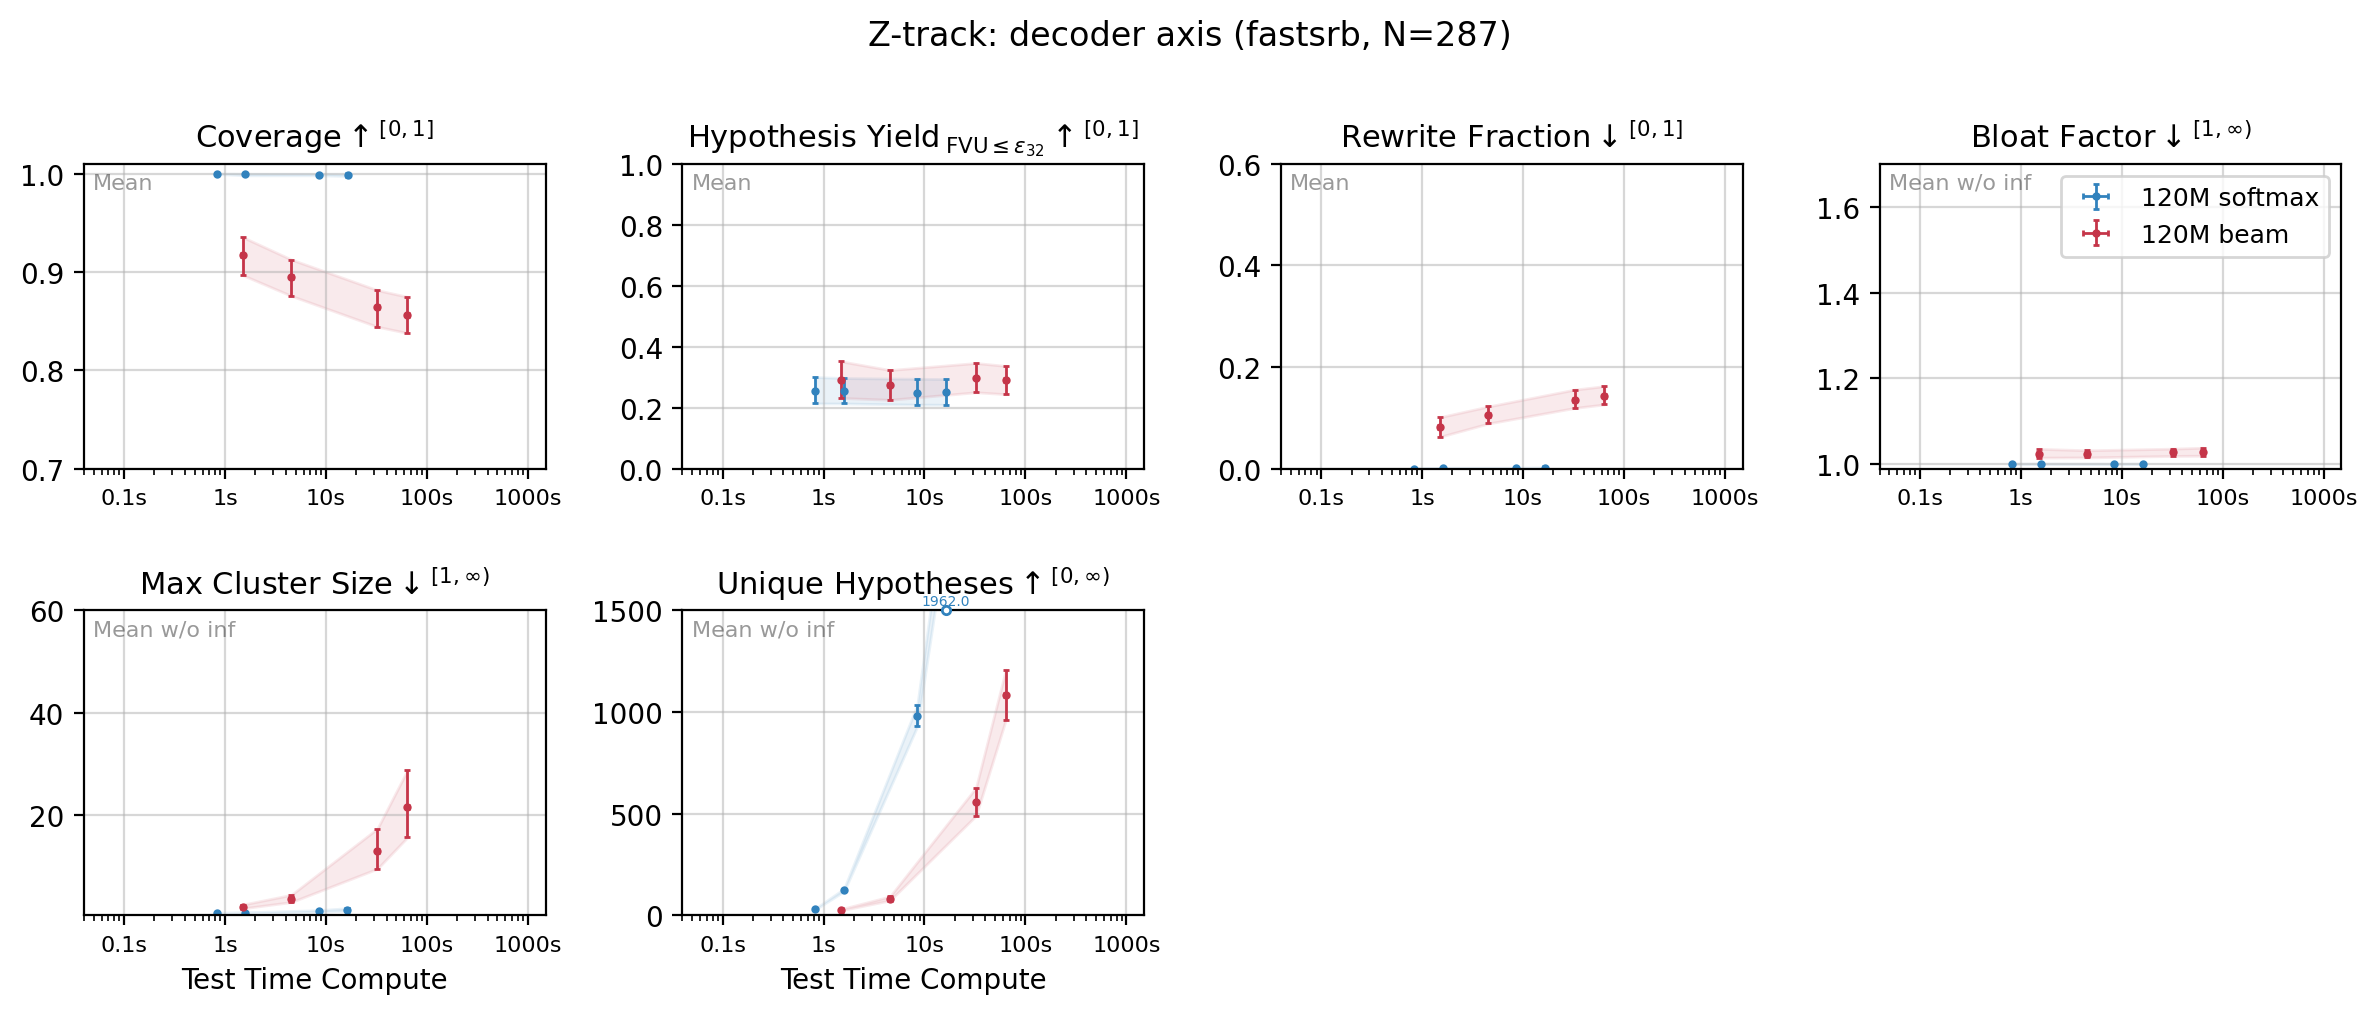

In [16]:
z_track = [
    ('v23.0-120M-softmax', 'choices',    '#3182BD', '120M softmax'),
    ('v23.0-120M-beam',    'beam_width', '#c53549', '120M beam'),
]
plot_track(z_track, save_as='z_track_metrics_vs_compute.svg', title_suffix='Z-track: decoder axis (fastsrb, N=287)')


## Cross-axis snapshot at matched compute (~3s fit_time)

Direct comparison of the four configurations on a single panel grid: this
exposes the cross-axis story — *training without simplification* (U100) and
*beam decoding* (120M-beam) shift different fingerprint axes, with both
ending up at elevated concentration but for distinct reasons.


Saved /home/psaegert/Projects/flash-ansr/results/figures/system_effect/cross_axis_metrics_vs_compute.svg


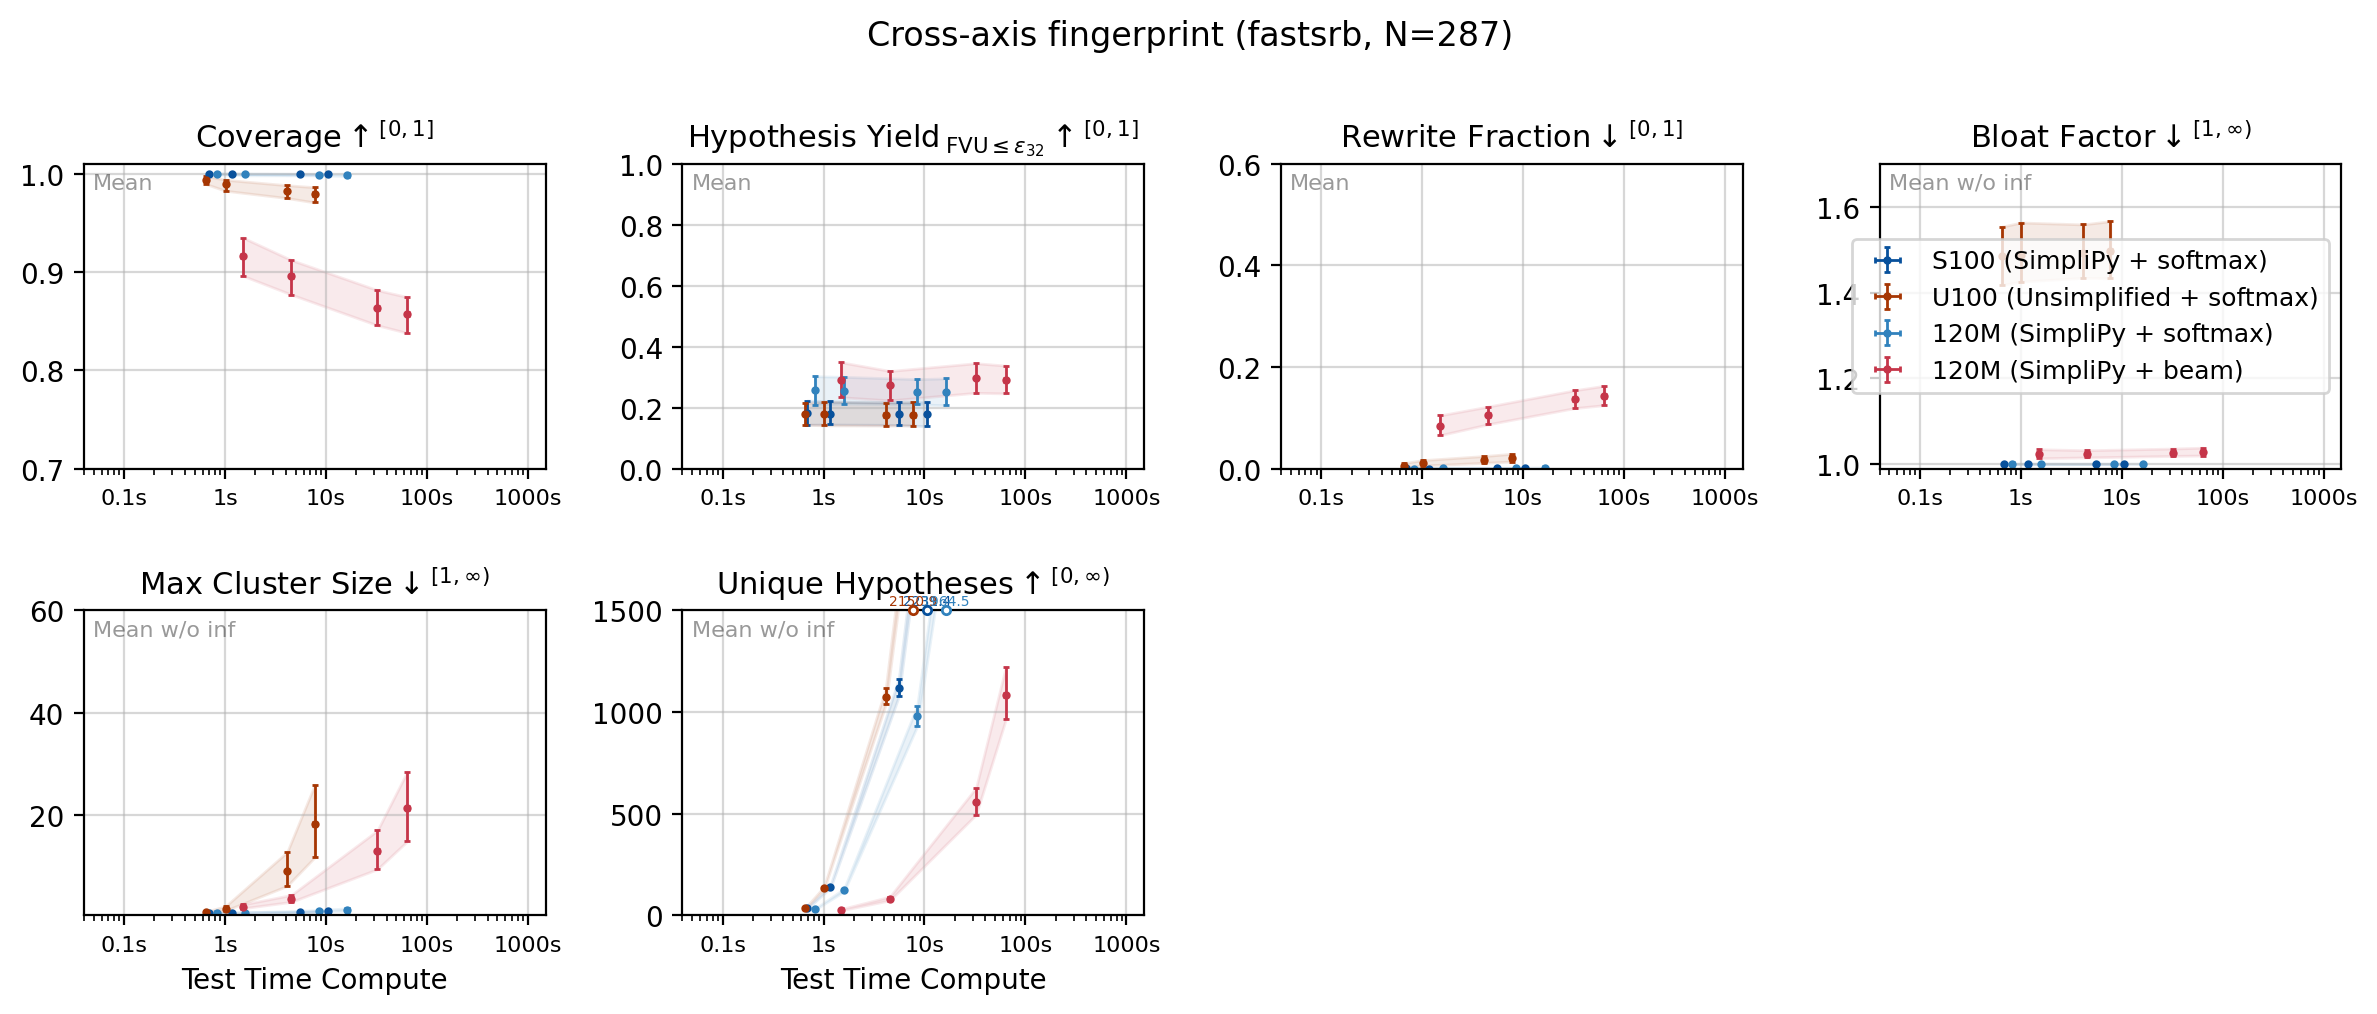

In [17]:
cross_axis = [
    ('v23.0-20M-A-S100',  'choices',    '#08519C', 'S100 (SimpliPy + softmax)'),
    ('v23.0-20M-A-U100',  'choices',    '#A63603', 'U100 (Unsimplified + softmax)'),
    ('v23.0-120M-softmax','choices',    '#3182BD', '120M (SimpliPy + softmax)'),
    ('v23.0-120M-beam',   'beam_width', '#c53549', '120M (SimpliPy + beam)'),
]
plot_track(cross_axis, save_as='cross_axis_metrics_vs_compute.svg', title_suffix='Cross-axis fingerprint (fastsrb, N=287)')


## Main-text summary table at the ~10s inference-time anchor

A single anchor compute point per row (chosen so each configuration's mean inference time per problem is roughly 10 s, matching the consistency target of the standard test-time-compute scaling evaluation in App.~\ref{app:detailed_test_time_scaling}). All four fingerprint axes plus mean fit time per sample, designed for inclusion in the camera-ready main text instead of multi-panel scaling figures (kept above for App N / sensitivity studies).

Format: `mean [95% CI lower, upper]` from a 1k-resample bootstrap. Configurations not yet probed at their target anchor (e.g. beam decoding at the larger c, while Solomon's queue is still running) appear with a `(pending)` marker; the table regenerates from `results` so it auto-updates once the dump lands.


In [18]:
import pandas as pd
from IPython.display import display, Markdown

# Anchor: 4096 candidates per problem (fixed-candidate budget; wall times
# vary across rows --- 20M softmax models hit ~10s, 120M softmax ~16s,
# 120M beam ~64s --- so the anchor is a compute *budget*, not a wall-time).
CHOICES_ANCHOR = 4096

# Six rows: 120M decoder axis (top), 20M training-data axis (bottom).
table_configs = [
    # (display_label, model_key)
    ('120M baseline (softmax)',         'v23.0-120M-softmax'),
    ('120M baseline (beam)',            'v23.0-120M-beam'),
    ('20M, SimpliPy 100M expressions',     'v23.0-20M-A-S100'),
    ('20M, Unsimplified 100M expressions', 'v23.0-20M-A-U100'),
    ('20M, SimpliPy 10M expressions',      'v23.0-20M-A-S10'),
    ('20M, SymPy 10M expressions',         'v23.0-20M-A-Y10'),
]

# Columns in display order: cost, classical headline, fingerprint axes used in
# the paper (Rewrite Frac. = 1 - Coverage; Bloat is the per-candidate raw/canonical
# ratio re-anchored to a fractional-growth percentage --- the same definition the
# paper uses since the c=4096 redefinition in §4.4). Yield (quality axis) and PFD
# were dropped from the paper because the Rewrite Frac. column carries the
# mode-collapse signal more cleanly --- the diagnostic still computes them.
#
# Per-column display transform: (offset, factor) applied to mean and CI before
# rendering. (0, 1) is identity. Bloat uses (1, 100): subtract 1 to map the raw
# ratio [1, ∞) onto [0, ∞), then multiply by 100 to express it as a percentage.
table_metrics = [
    # (key, header, stat, fmt, offset, factor)
    ('fit_time',                  'Time (s)',         naninfmean,  '{:.2f}', 0.0,   1.0),
    ('numeric_recovery_val',      'vNRR',             np.nanmean,  '{:.3f}', 0.0,   1.0),
    ('concentration',             'Rewrite Frac.',    np.nanmean,  '{:.3f}', 0.0,   1.0),
    ('surface_form',              'Bloat (\\%)',      naninfmean,  '{:.1f}', 1.0, 100.0),
    ('predicted_total_nestedness', 'Total Nest.',     naninfmean,  '{:.2f}', 0.0,   1.0),
]

def _ci_str(rec, key, stat, fmt, offset=0.0, factor=1.0):
    if key not in rec or len(rec[key]) == 0:
        return '—'
    arr = rec[key]
    if not np.any(np.isfinite(arr)):
        return '—'
    m, lo, hi = bootstrapped_metric_ci(arr, stat, n=1e3, interval=0.95)
    m, lo, hi = (m - offset) * factor, (lo - offset) * factor, (hi - offset) * factor
    return f'{fmt.format(m)} [{fmt.format(lo)}, {fmt.format(hi)}]'

rows = []
for label, model_key in table_configs:
    cs = results.get(model_key, {}).get('results', {}).get(TEST_SET, {})
    if CHOICES_ANCHOR not in cs:
        rows.append({'Configuration': f'{label} — (pending c={CHOICES_ANCHOR})',
                     **{h: '—' for _, h, *_ in table_metrics}})
        continue
    rec = cs[CHOICES_ANCHOR]
    row = {'Configuration': label}
    for metric, header, stat, fmt, offset, factor in table_metrics:
        row[header] = _ci_str(rec, metric, stat, fmt, offset, factor)
    rows.append(row)

df = pd.DataFrame(rows)

# Plain-text view in the notebook
print(df.to_string(index=False))

# Render as Markdown for inline display, and emit a LaTeX (booktabs) version for the paper.
display(Markdown(df.to_markdown(index=False)))

print('\n--- LaTeX (booktabs, paste into paper App. N as tab:fingerprint_full) ---\n')
print(df.to_latex(
    index=False,
    escape=False,
    column_format='l' + 'r' * (len(df.columns) - 1),
    caption=(f'Hypothesis-space coverage fingerprint and headline metrics at the $c = {CHOICES_ANCHOR}$ '
             'fixed-candidate anchor on fastsrb. '
             'Per-cell entries report mean and 95\\% bootstrap CI (N $\\approx$ 287 stratified samples; '
             'samples returning empty candidate sets are excluded). '
             'vNRR = validation Numeric Recovery Rate (per-problem any-candidate FVU $\\le \\epsilon_{32}$); '
             'Rewrite Frac. = $1 - $ Coverage = canonical-equivalent rewrite share among returned candidates; '
             'Bloat (\\%) = mean per-candidate fractional length growth over the canonical form '
             '(i.e., $\\mathbb{E}_c[|c|/|\\mathrm{canon}(c)|] - 1$, reported in percent); '
             'Total Nest. = total nestedness of the best returned candidate. '
             'Wall times vary across rows because the $c$ axis fixes the candidate budget, not inference time.'),
    label='tab:fingerprint_full',
))


                                Configuration             Time (s)                 vNRR        Rewrite Frac.         Bloat Factor       Total Nest.
                      120M baseline (softmax) 16.34 [15.89, 16.73] 0.620 [0.564, 0.680] 0.002 [0.001, 0.003] 1.001 [1.001, 1.002] 0.64 [0.53, 0.76]
                         120M baseline (beam) 63.95 [61.97, 66.06] 0.529 [0.471, 0.588] 0.144 [0.126, 0.163] 1.029 [1.020, 1.039] 0.50 [0.42, 0.60]
               20M, SimpliPy 100M expressions 10.51 [10.25, 10.77] 0.571 [0.516, 0.631] 0.001 [0.000, 0.001] 1.001 [1.001, 1.001] 0.60 [0.50, 0.70]
           20M, Unsimplified 100M expressions    7.74 [7.49, 7.96] 0.571 [0.509, 0.627] 0.021 [0.014, 0.029] 1.498 [1.440, 1.571] 0.81 [0.71, 0.92]
                20M, SimpliPy 10M expressions 10.84 [10.60, 11.07] 0.516 [0.460, 0.575] 0.000 [0.000, 0.000] 1.001 [1.001, 1.001] 0.51 [0.42, 0.61]
20M, SymPy 10M expressions — (pending c=4096)                    —                    —                    —    

| Configuration                                 | Time (s)             | vNRR                 | Rewrite Frac.        | Bloat Factor         | Total Nest.       |
|:----------------------------------------------|:---------------------|:---------------------|:---------------------|:---------------------|:------------------|
| 120M baseline (softmax)                       | 16.34 [15.89, 16.73] | 0.620 [0.564, 0.680] | 0.002 [0.001, 0.003] | 1.001 [1.001, 1.002] | 0.64 [0.53, 0.76] |
| 120M baseline (beam)                          | 63.95 [61.97, 66.06] | 0.529 [0.471, 0.588] | 0.144 [0.126, 0.163] | 1.029 [1.020, 1.039] | 0.50 [0.42, 0.60] |
| 20M, SimpliPy 100M expressions                | 10.51 [10.25, 10.77] | 0.571 [0.516, 0.631] | 0.001 [0.000, 0.001] | 1.001 [1.001, 1.001] | 0.60 [0.50, 0.70] |
| 20M, Unsimplified 100M expressions            | 7.74 [7.49, 7.96]    | 0.571 [0.509, 0.627] | 0.021 [0.014, 0.029] | 1.498 [1.440, 1.571] | 0.81 [0.71, 0.92] |
| 20M, SimpliPy 10M expressions                 | 10.84 [10.60, 11.07] | 0.516 [0.460, 0.575] | 0.000 [0.000, 0.000] | 1.001 [1.001, 1.001] | 0.51 [0.42, 0.61] |
| 20M, SymPy 10M expressions — (pending c=4096) | —                    | —                    | —                    | —                    | —                 |


--- LaTeX (booktabs, paste into paper App. N as tab:fingerprint_full) ---

\begin{table}
\caption{Hypothesis-space coverage fingerprint and headline metrics at the $c = 4096$ fixed-candidate anchor on fastsrb. Per-cell entries report mean and 95\% bootstrap CI (N $\approx$ 287 stratified samples; samples returning empty candidate sets are excluded). vNRR = validation Numeric Recovery Rate (per-problem any-candidate FVU $\le \epsilon_{32}$); Rewrite Frac. = $1 - $ Coverage = canonical-equivalent rewrite share among returned candidates; Bloat Factor = mean raw-token-length / canonical-length per candidate; Total Nest. = total nestedness of the best returned candidate. Wall times vary across rows because the $c$ axis fixes the candidate budget, not inference time.}
\label{tab:fingerprint_full}
\begin{tabular}{lrrrrr}
\toprule
Configuration & Time (s) & vNRR & Rewrite Frac. & Bloat Factor & Total Nest. \\
\midrule
120M baseline (softmax) & 16.34 [15.89, 16.73] & 0.620 [0.564, 0.680] & 0.0

---

To extend: add Y10 (SymPy at 10M) and B-track (architecture variants) probes
when their dumps land in `results/system_effect/`. The `PROBES` list at the
top is the only place that needs editing; the rest of the notebook adapts
automatically via the per-track plotting helper.


/tmp/ipykernel_10985/3195109903.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0.045, 1, 0.96))


Saved /home/psaegert/Projects/flash-ansr/results/figures/system_effect/system_effect_summary_forest_c4096.pdf


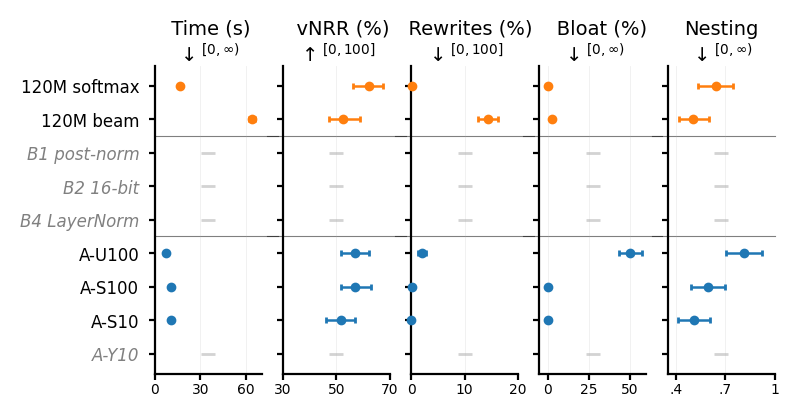

In [97]:
import matplotlib.pyplot as plt
from flash_ansr.eval.formatting import arrow_notation

# Full row inventory: every planned variant gets a slot, even if its dump
# hasn't landed yet --- pending rows render as a gray dash so the figure
# scopes the §8 story at a glance and auto-fills as data arrives.
forest_configs = [
    # §8.3 decoder axis (Z-track)
    ('120M softmax',  'v23.0-120M-softmax',      'decoder'),
    ('120M beam',     'v23.0-120M-beam',         'decoder'),
    # §8.2 architecture axis (B-track) --- all pending
    ('B1 post-norm',  'v23.0-120M-B1-postnorm',  'arch'),
    ('B2 16-bit',     'v23.0-120M-B2-16bit',     'arch'),
    ('B4 LayerNorm',  'v23.0-120M-B4-layernorm', 'arch'),
    # §8.1 training-data axis (A-track)
    ('A-U100',        'v23.0-20M-A-U100',        'data'),
    ('A-S100',        'v23.0-20M-A-S100',        'data'),
    ('A-S10',         'v23.0-20M-A-S10',         'data'),
    ('A-Y10',         'v23.0-20M-A-Y10',         'data'),
]
group_color = {'decoder': 'tab:orange', 'arch': 'tab:green', 'data': 'tab:blue'}
group_label = {'decoder': '§8.3 decoder', 'arch': '§8.2 arch.', 'data': '§8.1 data'}

# Per-panel x-axis knobs --- edit `xlim`, `xticks`, `xticklabels`, `factor`,
# `offset`, and `arrow` here to tune the figure.
#   offset       : subtracted from the raw data BEFORE `factor` is applied.
#                  Use it to re-anchor Bloat: the raw ratio sits in [1, ∞)
#                  with 1 = canonical; with offset=1 and factor=100 it
#                  becomes "Bloat (%)" in [0, ∞), matching the paper's
#                  redefinition of Bloat as fractional length growth over
#                  canonical (§4.4).
#   factor       : multiplies (data - offset) before plotting (e.g. 100 -> %).
#                  All other panel knobs (xref/xlim/xticks/arrow bounds) are in
#                  display units, i.e. post-transform.
#   xref         : dotted reference line at the metric "ideal"
#                  (0 = no rewriting, 0 = no bloat). None disables it.
#   xlim         : (lo, hi) tuple or None for matplotlib autoscale.
#   xticks       : list of tick positions, or None for autoscale.
#   xticklabels  : list of strings (must match `xticks` length), or None
#                  to keep the default numeric formatting.
#   arrow        : kwargs forwarded to `arrow_notation(...)` -> rendered as
#                  $\uparrow^{[lo,hi]}$ / $\downarrow^{[lo,hi]}$ in the title.
#                  objective=1 (higher better) / -1 (lower better);
#                  bounds use `np.inf` for open ends.
panel_specs = {
    'fit_time': {
        'title':  ' Time (s)',
        'xscale': 'linear',
        'offset': 0.0,
        'factor': 1.0,
        'xref':   None,
        'xlim':   (0, 70),
        'xticks': [0, 30, 60],
        'xticklabels': ["0", "30", "60"],
        'arrow':  dict(objective=-1, lower=0, upper=np.inf),
    },
    'numeric_recovery_val': {
        'title':  '  vNRR (%)',
        'xscale': 'linear',
        'offset': 0.0,
        'factor': 100.0,           # fraction -> percent
        'xref':   None,
        'xlim':   (30, 70),
        'xticks': [30, 50, 70],
        'xticklabels': ['30', '50', '70'],
        'arrow':  dict(objective=1, lower=0, upper=100),
    },
    'concentration': {
        'title':  '  Rewrites (%)',
        'xscale': 'linear',
        'offset': 0.0,
        'factor': 100.0,           # fraction -> percent
        'xref':   None,
        'xlim':   (0, 20),
        'xticks': [0, 10, 20],
        'xticklabels': ["0", "10", "20"],
        'arrow':  dict(objective=-1, lower=0, upper=100),
    },
    'surface_form': {
        'title':  '   Bloat (%)',
        'xscale': 'linear',
        'offset': 1.0,             # raw bloat ratio in [1, ∞) -> Bloat in [0, ∞)
        'factor': 100.0,           # excess ratio -> percent
        'xref':   None,
        'xlim':   (-5, 60),
        'xticks': [0, 25, 50],
        'xticklabels': ['0', '25', '50'],
        'arrow':  dict(objective=-1, lower=0, upper=np.inf),
    },
    'predicted_total_nestedness': {
        'title':  'Nesting',
        'xscale': 'linear',
        'offset': 0.0,
        'factor': 1.0,
        'xref':   None,
        'xlim':   (0.35, 1),
        'xticks': [0.4, 0.7, 1.0],
        'xticklabels': ['.4', '.7', '1'],
        'arrow':  dict(objective=-1, lower=0, upper=np.inf),
    },
}

# Compact-arrow renderer: drop the space after the bracketed comma so the
# superscript fits inside the narrow panel titles.
def _arrow_compact(**kwargs) -> str:
    return f"${arrow_notation(**kwargs).replace(', ', ',')}$"

n_rows = len(forest_configs)
ypos    = np.arange(n_rows)[::-1]                      # top row = first config
ylabels = [lbl for lbl, _, _ in forest_configs]
ycolors = [group_color[g] for _, _, g in forest_configs]

# Group-boundary y-positions (between consecutive groups).
group_ids = [g for _, _, g in forest_configs]
divider_y = [n_rows - 1 - i + 0.5
             for i in range(1, n_rows) if group_ids[i] != group_ids[i - 1]]

fig, axes = plt.subplots(1, 5, figsize=(4.0, 2.0), dpi=200, sharey=True, gridspec_kw={'wspace': 0.2})

pending_rows = {p_idx: [] for p_idx in range(len(table_metrics))}

for p_idx, (metric_key, header, stat, _fmt, *_) in enumerate(table_metrics):
    ax = axes[p_idx]
    spec = panel_specs[metric_key]
    offset = spec.get('offset', 0.0)
    factor = spec.get('factor', 1.0)

    for (_, model_key, group), y in zip(forest_configs, ypos):
        cs  = results.get(model_key, {}).get('results', {}).get(TEST_SET, {})
        rec = cs.get(CHOICES_ANCHOR)
        if (rec is None or metric_key not in rec or len(rec[metric_key]) == 0
                or not np.any(np.isfinite(rec[metric_key]))):
            pending_rows[p_idx].append(y)
            continue
        m, lo, hi = bootstrapped_metric_ci(rec[metric_key], stat,
                                           n=1e3, interval=0.95)
        m, lo, hi = (m - offset) * factor, (lo - offset) * factor, (hi - offset) * factor
        ax.errorbar(m, y, xerr=[[m - lo], [hi - m]],
                    fmt='o', color=group_color[group], ecolor=group_color[group],
                    elinewidth=0.9, capsize=1.2, markersize=2.5, zorder=3, clip_on=False)

    if spec['xscale'] == 'log':
        ax.set_xscale('log')
    if spec['xref'] is not None:
        ax.axvline(spec['xref'], color='gray', linewidth=0.5,
                   linestyle=':', alpha=0.7)
    if spec['xlim'] is not None:
        ax.set_xlim(spec['xlim'])
    if spec['xticks'] is not None:
        ax.set_xticks(spec['xticks'])
    if spec.get('xticklabels') is not None:
        ax.set_xticklabels(spec['xticklabels'])

    # Group-divider lines: drawn per-axis with overshoot into the wspace gap on
    # each side, so adjacent panels' lines overlap in the gap -> the divider
    # reads as one continuous stroke across the full row.
    is_first = (p_idx == 0)
    is_last  = (p_idx == len(axes) - 1)
    xlo = 0.0 if is_first else -0.15
    xhi = 1.0 if is_last  else  1.15
    for dy in divider_y:
        ax.plot([xlo, xhi], [dy, dy],
                transform=ax.get_yaxis_transform(),
                color='black', linewidth=0.4, alpha=0.5,
                clip_on=False, zorder=0)

    arrow = _arrow_compact(**spec['arrow'])
    ax.set_title(f'{spec["title"]}\n{arrow}', fontsize=7, pad=1.5)
    ax.tick_params(axis='x', labelsize=5, pad=1, length=2)
    ax.tick_params(axis='y', labelsize=6, length=2)
    ax.grid(axis='x', alpha=0.2, linewidth=0.3)
    ax.set_ylim(-0.6, n_rows - 0.4)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

# Pending-row placeholders: drawn AFTER autoscale, centered in axes fraction
# so they line up across panels regardless of x-scale.
for p_idx, ax in enumerate(axes):
    trans = ax.get_yaxis_transform()  # x = axes fraction, y = data coords
    for y in pending_rows[p_idx]:
        ax.plot(0.5, y, marker='_', color='lightgray',
                markersize=5, markeredgewidth=1.0,
                transform=trans, zorder=1, clip_on=False)

# Y-tick labels on the leftmost panel; gray-italic for pending rows.
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(ylabels)
fully_pending_keys = {
    mk for _, mk, _ in forest_configs
    if (results.get(mk, {}).get('results', {}).get(TEST_SET, {}).get(CHOICES_ANCHOR) is None)
}
for tick, (_, mk, _) in zip(axes[0].get_yticklabels(), forest_configs):
    if mk in fully_pending_keys:
        tick.set_color('gray')
        tick.set_style('italic')

fig.tight_layout(rect=(0, 0.045, 1, 0.96))

out = FIG_DIR / f'system_effect_summary_forest_c{CHOICES_ANCHOR}.pdf'
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'Saved {out}')
plt.show()
